In [ ]:
%pip install scikit-learn joblib matplotlib seaborn pandas numpy --quiet


In [ ]:
import pandas as pd # type: ignore
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
import matplotlib.ticker as mticker # type: ignore
import seaborn as sns # type: ignore
import json, os, joblib, warnings # type: ignore
warnings.filterwarnings("ignore")

In [ ]:
from sklearn.ensemble import IsolationForest # type: ignore
from sklearn.neighbors import LocalOutlierFactor # type: ignore
from sklearn.preprocessing import StandardScaler # type: ignore
from sklearn.metrics import ( # type: ignore
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, ConfusionMatrixDisplay
)

In [4]:
np.random.seed(42)

In [5]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size":        11,
})

LOAD DATA

In [7]:
train_df = pd.read_csv("meditrust_data/train_data_calibrated.csv")
test_df  = pd.read_csv("meditrust_data/test_data_calibrated.csv")

In [10]:
train_df.info()
train_df.shape

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                10000 non-null  str    
 1   rx_date                   10000 non-null  str    
 2   facility                  10000 non-null  str    
 3   age_months                10000 non-null  int64  
 4   age_years                 10000 non-null  float64
 5   age_group                 10000 non-null  str    
 6   sex                       10000 non-null  str    
 7   weight_kg                 10000 non-null  float64
 8   drug_name                 10000 non-null  str    
 9   drug_class                10000 non-null  str    
 10  formulation               10000 non-null  str    
 11  dose_mg                   10000 non-null  float64
 12  freq_per_day              10000 non-null  int64  
 13  max_allowed_dose_mg       10000 non-null  float64
 14  is_anomaly        

(10000, 33)

In [11]:
test_df.info()
test_df.shape   

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                10000 non-null  str    
 1   rx_date                   10000 non-null  str    
 2   facility                  10000 non-null  str    
 3   age_months                10000 non-null  int64  
 4   age_years                 10000 non-null  float64
 5   age_group                 10000 non-null  str    
 6   sex                       10000 non-null  str    
 7   weight_kg                 10000 non-null  float64
 8   drug_name                 10000 non-null  str    
 9   drug_class                10000 non-null  str    
 10  formulation               10000 non-null  str    
 11  dose_mg                   10000 non-null  float64
 12  freq_per_day              10000 non-null  int64  
 13  max_allowed_dose_mg       10000 non-null  float64
 14  is_anomaly        

(10000, 33)

In [12]:
train_df.head(10)

,patient_id,rx_date,facility,age_months,age_years,age_group,sex,weight_kg,drug_name,drug_class,...,drug_class_num,freq_ratio,guideline_max_freq,is_above_max_dose,is_below_min_therapeutic,is_freq_above_guideline,is_age_contraindicated,is_tablet_split,facility_type_num,dose_zscore
0,SYN-01446,2022-05-19,health_centre,14,1.2,toddler,F,10.7,Paracetamol,analgesic_antipyretic,...,0,0.5,6,0,0,0,0,1,1,0.5770
1,SYN-05401,2018-08-21,paediatric_ward,37,3.1,child,M,13.6,Ferrous_Sulfate,micronutrient,...,12,0.5,2,0,0,0,0,0,0,-1.0289
2,SYN-03928,2013-08-05,community_health,50,4.2,child,F,22.9,Cotrimoxazole,antibiotic_sulfonamide,...,7,1.0,2,0,0,0,0,0,3,-0.5322
3,SYN-04750,2013-09-30,paediatric_ward,9,0.8,infant,M,7.7,Artemether_Lumefantrine,antimalarial,...,10,1.0,2,0,0,0,0,0,0,0.8367
4,SYN-00572,2010-11-19,community_health,44,3.7,child,M,14.4,Paracetamol,analgesic_antipyretic,...,0,1.0,6,0,0,0,0,1,3,0.9213
5,SYN-02890,2021-12-03,health_centre,49,4.1,child,F,17.6,Artemether_Lumefantrine,antimalarial,...,10,1.0,2,0,0,0,0,0,1,0.2728
6,SYN-09137,2022-12-29,health_centre,45,3.8,child,M,15.7,Phenobarbital,anticonvulsant,...,8,1.0,2,0,0,0,0,1,1,0.0869
7,SYN-07390,2011-09-24,outpatient_clinic,28,2.3,toddler,F,18.5,Zinc_Sulfate,micronutrient,...,12,1.0,1,0,0,0,0,0,2,-0.6165
8,SYN-03786,2021-04-28,health_centre,6,0.5,infant,F,3.9,Amoxicillin,antibiotic_penicillin,...,6,1.0,3,0,0,0,0,1,1,0.9969
9,SYN-04643,2021-03-18,health_centre,32,2.7,toddler,F,18.1,Zinc_Sulfate,micronutrient,...,12,1.0,1,0,0,0,0,0,1,-0.5905


In [13]:
train_df.tail(10)

,patient_id,rx_date,facility,age_months,age_years,age_group,sex,weight_kg,drug_name,drug_class,...,drug_class_num,freq_ratio,guideline_max_freq,is_above_max_dose,is_below_min_therapeutic,is_freq_above_guideline,is_age_contraindicated,is_tablet_split,facility_type_num,dose_zscore
9990,SYN-02412,2021-06-16,paediatric_ward,12,1.0,toddler,F,14.3,Paracetamol,analgesic_antipyretic,...,0,1.000,6,0,0,0,0,0,0,0.5832
9991,SYN-01247,2014-04-10,health_centre,64,5.3,child,M,11.4,Paracetamol,analgesic_antipyretic,...,0,1.000,6,0,0,0,0,0,1,-0.3960
9992,SYN-06963,2013-12-24,health_centre,7,0.6,infant,F,7.2,Ceftriaxone,antibiotic_cephalosporin,...,4,1.000,2,0,0,0,0,0,1,-1.4738
9993,SYN-02688,2011-08-08,paediatric_ward,31,2.6,toddler,F,17.6,Ferrous_Sulfate,micronutrient,...,12,1.000,2,0,0,0,0,0,0,0.8316
9994,SYN-04310,2016-05-11,paediatric_ward,7,0.6,infant,M,4.5,Metronidazole,antibiotic_nitroimidazole,...,5,1.000,3,0,0,0,0,0,0,-1.5909
9995,SYN-06693,2015-04-19,health_centre,3,0.2,infant,F,5.4,Amoxicillin,antibiotic_penicillin,...,6,1.000,3,0,0,0,0,1,1,1.1039
9996,SYN-02210,2015-05-01,health_centre,96,8.0,child,M,36.0,Ferrous_Sulfate,micronutrient,...,12,1.000,2,0,0,0,0,0,1,0.1261
9997,SYN-07309,2015-12-18,community_health,22,1.8,toddler,F,11.9,Paracetamol,analgesic_antipyretic,...,0,0.667,6,0,0,0,0,0,3,-0.8153
9998,SYN-04476,2011-12-02,outpatient_clinic,87,7.2,child,M,20.2,Zinc_Sulfate,micronutrient,...,12,1.000,1,0,0,0,0,0,2,-0.7148
9999,SYN-00223,2022-01-10,health_centre,9,0.8,infant,F,4.5,Cotrimoxazole,antibiotic_sulfonamide,...,7,1.000,2,0,0,0,0,0,1,-0.3711


DATA CLEANING

Missing Values


In [14]:
null_counts = train_df.isnull().sum()
null_pct    = (null_counts / len(train_df) * 100).round(2)

null_report = pd.DataFrame({
    "null_count": null_counts,
    "null_pct":   null_pct
}).query("null_count > 0")

if len(null_report) == 0:
    print("✓ No missing values in training set — data is clean.")
else:
    print("Columns with missing values:")
    print(null_report)

# Same check on test set
test_nulls = test_df.isnull().sum().sum()
print(f"\nTest set total nulls: {test_nulls}")

Columns with missing values:
             null_count  null_pct
flag_reason       10000     100.0

Test set total nulls: 8000


Duplicates

In [15]:
train_dups = train_df.duplicated().sum()
test_dups  = test_df.duplicated().sum()

print(f"Duplicate rows in training set : {train_dups}")
print(f"Duplicate rows in test set     : {test_dups}")

if train_dups > 0:
    train_df = train_df.drop_duplicates()
    print(f"Dropped {train_dups} duplicates. New shape: {train_df.shape}")
else:
    print("✓ No duplicates found.")


Duplicate rows in training set : 0
Duplicate rows in test set     : 0
✓ No duplicates found.


Data Type Verification

In [17]:
numeric_cols     = train_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = train_df.select_dtypes(include=["object"]).columns.tolist()

print(f"Numeric columns   ({len(numeric_cols)}) : {numeric_cols[:8]} ...")
print(f"\nCategorical cols  ({len(categorical_cols)}) : {categorical_cols}")
print("\n✓ Categorical columns are metadata only (patient_id, drug_name, etc.)")
print("  Model uses encoded numeric versions (age_group_num, drug_class_num, etc.)")

Numeric columns   (24) : ['age_months', 'age_years', 'weight_kg', 'dose_mg', 'freq_per_day', 'max_allowed_dose_mg', 'is_anomaly', 'flag_reason'] ...

Categorical cols  (9) : ['patient_id', 'rx_date', 'facility', 'age_group', 'sex', 'drug_name', 'drug_class', 'formulation', 'anomaly_type']

✓ Categorical columns are metadata only (patient_id, drug_name, etc.)
  Model uses encoded numeric versions (age_group_num, drug_class_num, etc.)


Impossible Value Check

In [19]:
checks = {
    "weight_kg   must be > 1.5":         (train_df["weight_kg"]    > 1.5).all(),
    "age_months  must be >= 1":           (train_df["age_months"]   >= 1).all(),
    "dose_mg     must be > 0":            (train_df["dose_mg"]      > 0).all(),
    "freq_per_day must be in [1,6]":      train_df["freq_per_day"].between(1, 6).all(),
    "dose_per_kg must be > 0":            (train_df["dose_per_kg"]  > 0).all(),
}

all_passed = True
for check, result in checks.items():
    status = "✓" if result else "✗ FAILED"
    print(f"  {status}  {check}")
    if not result:
        all_passed = False

print(f"\n{'✓ All sanity checks passed.' if all_passed else '⚠ Some checks failed — investigate above.'}")


  ✓  weight_kg   must be > 1.5
  ✓  age_months  must be >= 1
  ✓  dose_mg     must be > 0
  ✓  freq_per_day must be in [1,6]
  ✓  dose_per_kg must be > 0

✓ All sanity checks passed.


EXPOLORATORY DATA ANALYSIS (EDA)

In [20]:
key_cols = [
    "age_months", "weight_kg", "dose_mg",
    "freq_per_day", "dose_per_kg", "dose_to_max_ratio",
    "deviation_from_guideline", "daily_dose_per_kg"
]

stats = train_df[key_cols].describe().round(3)
print("=== KEY FEATURE STATISTICS (training set) ===")
stats


=== KEY FEATURE STATISTICS (training set) ===


,age_months,weight_kg,dose_mg,freq_per_day,dose_per_kg,dose_to_max_ratio,deviation_from_guideline,daily_dose_per_kg
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,35.723,15.537,129.324,2.650,8.544,0.336,-0.001,26.227
std,36.403,10.562,138.204,1.364,6.150,0.275,0.157,22.826
min,1.000,2.200,3.700,1.000,0.257,0.018,-0.606,0.257
25%,12.000,8.900,40.475,2.000,4.155,0.147,-0.096,6.054
50%,25.000,13.200,93.400,2.000,8.430,0.246,0.000,22.754
75%,44.000,18.700,169.800,3.000,12.072,0.426,0.091,41.013
max,468.000,119.100,2029.700,6.000,50.483,1.030,0.623,99.167


AgeGroup Distribution

In [21]:
age_dist = train_df["age_group"].value_counts()
age_pct  = (age_dist / len(train_df) * 100).round(1)

print("Age group distribution:")
print("-" * 35)
for grp in ["neonate","infant","toddler","child","adolescent"]:
    if grp in age_dist.index:
        bar = "█" * int(age_pct[grp] / 2)
        print(f"  {grp:<12} {age_dist[grp]:>5}  ({age_pct[grp]:>5.1f}%)  {bar}")

Age group distribution:
-----------------------------------
  infant        2269  ( 22.7%)  ███████████
  toddler       4212  ( 42.1%)  █████████████████████
  child         3255  ( 32.6%)  ████████████████
  adolescent     264  (  2.6%)  █


Drug Distribution

In [22]:
drug_dist = train_df["drug_name"].value_counts()
drug_pct  = (drug_dist / len(train_df) * 100).round(1)

print("Drug distribution:")
print("-" * 55)
for drug, count in drug_dist.items():
    bar = "█" * int(drug_pct[drug] / 1.5)
    print(f"  {drug:<30} {count:>5}  ({drug_pct[drug]:>5.1f}%)  {bar}")


Drug distribution:
-------------------------------------------------------
  Paracetamol                     2743  ( 27.4%)  ██████████████████
  Amoxicillin                     1731  ( 17.3%)  ███████████
  Cotrimoxazole                   1051  ( 10.5%)  ███████
  Zinc_Sulfate                     954  (  9.5%)  ██████
  Artemether_Lumefantrine          891  (  8.9%)  █████
  Zidovudine_Lamivudine            600  (  6.0%)  ████
  Ferrous_Sulfate                  499  (  5.0%)  ███
  Phenobarbital                    399  (  4.0%)  ██
  Metronidazole                    397  (  4.0%)  ██
  Fluconazole                      333  (  3.3%)  ██
  Ceftriaxone                      212  (  2.1%)  █
  Gentamicin                       190  (  1.9%)  █


Anomaly Breakdown

In [23]:
print("=== TEST SET — Anomaly breakdown ===")
anomaly_df = test_df[test_df["is_anomaly"] == 1]
atype_dist = anomaly_df["anomaly_type"].value_counts()
atype_pct  = (atype_dist / len(anomaly_df) * 100).round(1)

print(f"Total anomalies : {len(anomaly_df)} / {len(test_df)} ({len(anomaly_df)/len(test_df)*100:.1f}%)")
print("-" * 55)
for atype, count in atype_dist.items():
    bar = "█" * int(atype_pct[atype] / 2)
    print(f"  {atype:<30} {count:>4}  ({atype_pct[atype]:>5.1f}%)  {bar}")

=== TEST SET — Anomaly breakdown ===
Total anomalies : 2000 / 10000 (20.0%)
-------------------------------------------------------
  tenfold_overdose                610  ( 30.5%)  ███████████████
  overdose_2x                     570  ( 28.5%)  ██████████████
  dose_exceeds_max                495  ( 24.8%)  ████████████
  frequency_error                 198  (  9.9%)  ████
  underdose                        99  (  5.0%)  ██
  age_contraindication             28  (  1.4%)  


Formulation Risk Analysis

In [24]:
split_pct = train_df["is_tablet_split"].mean() * 100
print(f"adult_tablet_split usage: {split_pct:.1f}%  (real data: 23.0%)")

# By drug
split_by_drug = (
    train_df.groupby("drug_name")["is_tablet_split"]
    .mean()
    .sort_values(ascending=False) * 100
).round(1)
print("\nTablet-split rate by drug:")
for drug, pct in split_by_drug.head(8).items():
    bar = "█" * int(pct / 3)
    print(f"  {drug:<30} {pct:.1f}%  {bar}")


adult_tablet_split usage: 20.0%  (real data: 23.0%)

Tablet-split rate by drug:
  Phenobarbital                  52.9%  █████████████████
  Cotrimoxazole                  37.6%  ████████████
  Amoxicillin                    34.5%  ███████████
  Zidovudine_Lamivudine          17.0%  █████
  Paracetamol                    14.4%  ████
  Gentamicin                     13.2%  ████
  Metronidazole                  12.3%  ████
  Zinc_Sulfate                   8.1%  ██


VISUALISATIONS


Age Weight Distributions

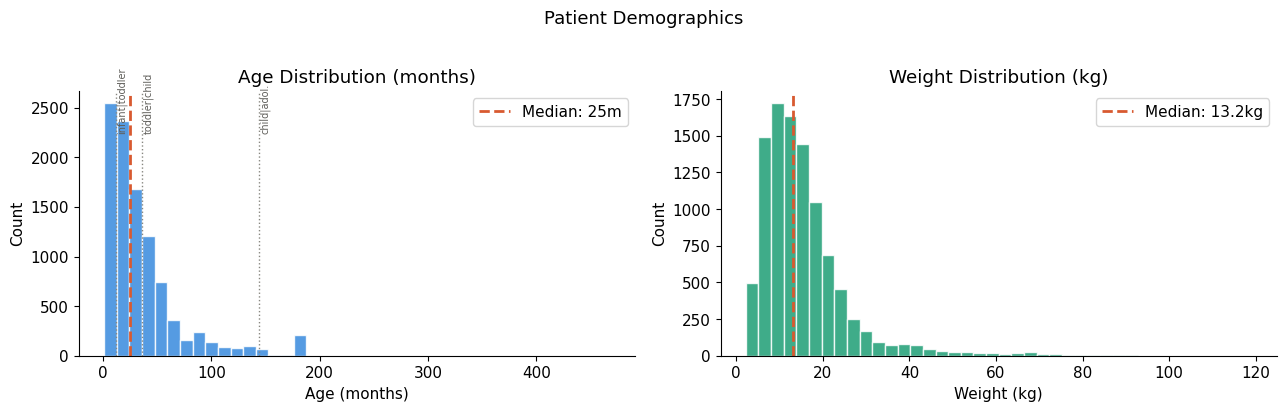

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Age distribution
axes[0].hist(train_df["age_months"], bins=40, color="#378ADD", alpha=0.85, edgecolor="white")
axes[0].axvline(train_df["age_months"].median(), color="#D85A30", lw=2, linestyle="--",
                label=f"Median: {train_df['age_months'].median():.0f}m")
axes[0].set_title("Age Distribution (months)")
axes[0].set_xlabel("Age (months)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Add age group labels
for boundary, label in [(12,"infant|toddler"), (36,"toddler|child"), (144,"child|adol.")]:
    axes[0].axvline(boundary, color="#888780", lw=1, linestyle=":")
    axes[0].text(boundary+1, axes[0].get_ylim()[1]*0.85, label,
                 fontsize=7, color="#5F5E5A", rotation=90)

# Weight distribution
axes[1].hist(train_df["weight_kg"], bins=40, color="#1D9E75", alpha=0.85, edgecolor="white")
axes[1].axvline(train_df["weight_kg"].median(), color="#D85A30", lw=2, linestyle="--",
                label=f"Median: {train_df['weight_kg'].median():.1f}kg")
axes[1].set_title("Weight Distribution (kg)")
axes[1].set_xlabel("Weight (kg)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.suptitle("Patient Demographics", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("plot_demographics.png", dpi=150, bbox_inches="tight")
plt.show()

Weight vs Age Scatter

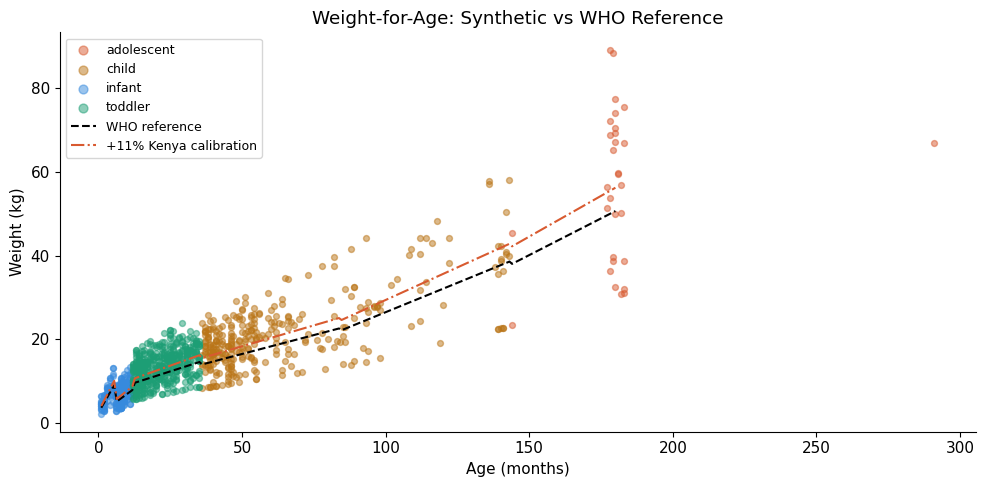

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = {"neonate":"#7F77DD","infant":"#378ADD","toddler":"#1D9E75",
          "child":"#BA7517","adolescent":"#D85A30"}

for grp, grp_df in train_df.sample(1000, random_state=42).groupby("age_group"):
    ax.scatter(grp_df["age_months"], grp_df["weight_kg"],
               c=colors.get(grp, "#888780"), alpha=0.5, s=18, label=grp)

# WHO reference line (our base formula)
ages = np.linspace(1, 180, 200)
who  = []
for a in ages:
    if a < 6:   who.append(2.5 + a*1.2)
    elif a < 12:who.append(5.0 + (a-6)*0.5)
    elif a < 36:who.append(9.5 + (a-12)*0.22)
    elif a < 84:who.append(14.0 + (a-36)*0.18)
    elif a < 144:who.append(22.0 + (a-84)*0.28)
    else:       who.append(min(38.0 + (a-144)*0.35, 75.0))

ax.plot(ages, who, "k--", lw=1.5, label="WHO reference")
ax.plot(ages, [w*1.11 for w in who], color="#D85A30", lw=1.5,
        linestyle="-.", label="+11% Kenya calibration")

ax.set_xlabel("Age (months)")
ax.set_ylabel("Weight (kg)")
ax.set_title("Weight-for-Age: Synthetic vs WHO Reference")
ax.legend(markerscale=1.5, fontsize=9)
plt.tight_layout()
plt.savefig("plot_weight_age.png", dpi=150, bbox_inches="tight")
plt.show()

Drug Distribution Bar Graph

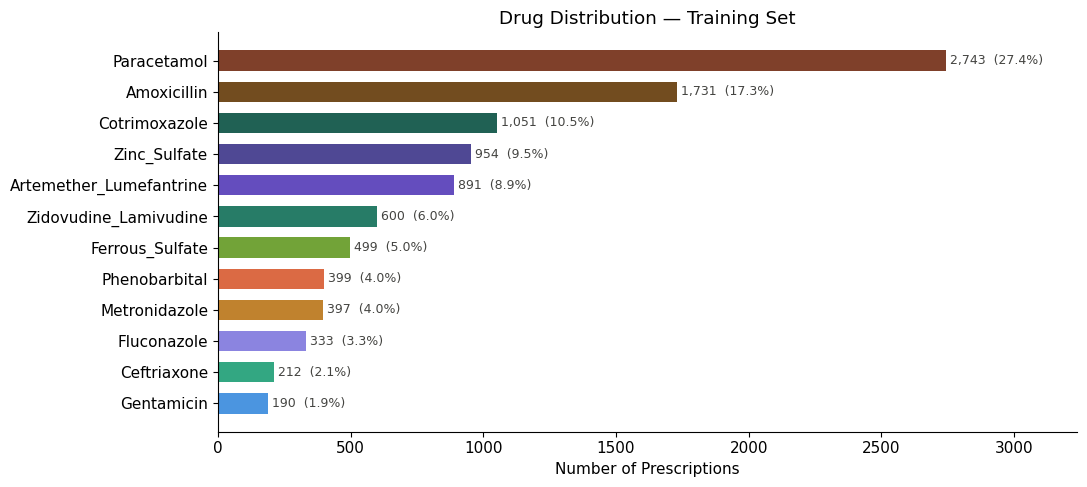

In [28]:
drug_counts = train_df["drug_name"].value_counts()
colors_bar  = ["#378ADD","#1D9E75","#7F77DD","#BA7517","#D85A30",
               "#639922","#0F6E56","#533AB7","#3C3489","#085041",
               "#633806","#712B13"]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(drug_counts.index[::-1], drug_counts.values[::-1],
               color=colors_bar[:len(drug_counts)], alpha=0.9, height=0.65)

for bar, count in zip(bars, drug_counts.values[::-1]):
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
            f"{count:,}  ({count/len(train_df)*100:.1f}%)",
            va="center", fontsize=9, color="#444441")

ax.set_xlabel("Number of Prescriptions")
ax.set_title("Drug Distribution — Training Set")
ax.set_xlim(0, drug_counts.max() * 1.18)
plt.tight_layout()
plt.savefig("plot_drugs.png", dpi=150, bbox_inches="tight")
plt.show()

Correlation HeatMap

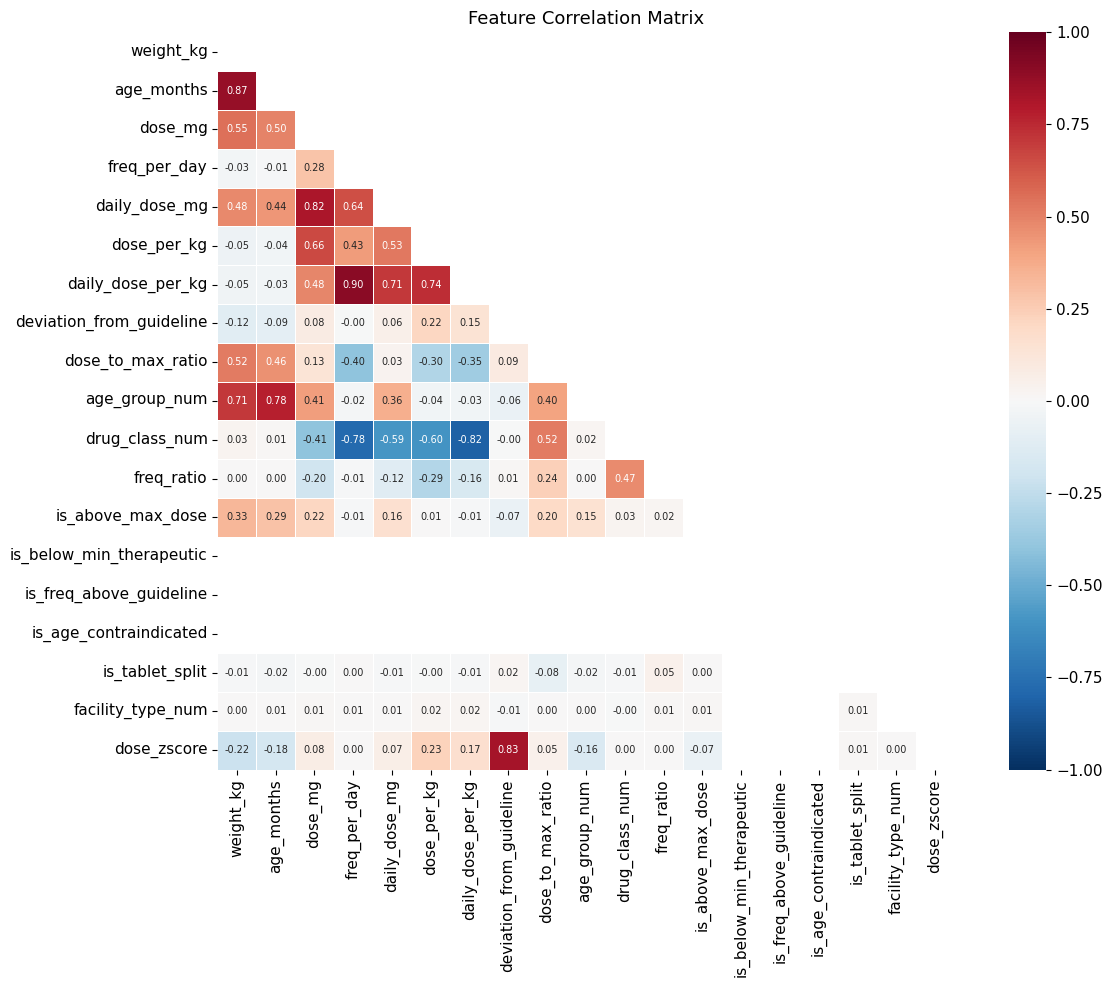


Top 10 strongest correlations:
  daily_dose_per_kg              × freq_per_day                    r=+0.899
  age_months                     × weight_kg                       r=+0.873
  dose_zscore                    × deviation_from_guideline        r=+0.835
  daily_dose_mg                  × dose_mg                         r=+0.817
  drug_class_num                 × daily_dose_per_kg               r=-0.816
  age_group_num                  × age_months                      r=+0.781
  drug_class_num                 × freq_per_day                    r=-0.780
  daily_dose_per_kg              × dose_per_kg                     r=+0.738
  daily_dose_per_kg              × daily_dose_mg                   r=+0.711
  age_group_num                  × weight_kg                       r=+0.705


In [29]:
MODEL_FEATURES = [
    "weight_kg", "age_months", "dose_mg", "freq_per_day",
    "daily_dose_mg", "dose_per_kg", "daily_dose_per_kg",
    "deviation_from_guideline", "dose_to_max_ratio",
    "age_group_num", "drug_class_num", "freq_ratio",
    "is_above_max_dose", "is_below_min_therapeutic",
    "is_freq_above_guideline", "is_age_contraindicated",
    "is_tablet_split", "facility_type_num", "dose_zscore",
]

corr = train_df[MODEL_FEATURES].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0,
            annot=True, fmt=".2f", annot_kws={"size": 7},
            linewidths=0.4, square=True, ax=ax,
            vmin=-1, vmax=1)
ax.set_title("Feature Correlation Matrix", fontsize=13)
plt.tight_layout()
plt.savefig("plot_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

# Print top correlations
print("\nTop 10 strongest correlations:")
corr_pairs = (corr.where(~mask).stack()
              .reset_index()
              .rename(columns={"level_0":"feat1","level_1":"feat2",0:"corr"}))
corr_pairs["abs_corr"] = corr_pairs["corr"].abs()
top = corr_pairs.sort_values("abs_corr", ascending=False).head(10)
for _, row in top.iterrows():
    print(f"  {row['feat1']:<30} × {row['feat2']:<30}  r={row['corr']:>+.3f}")


Anomaly Score Distribution by error type

In [ ]:
try:
    if_model
    scores = -if_model.score_samples(X_test_scaled)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Score distribution: normal vs anomaly
    score_normal  = scores[y_test == 0]
    score_anomaly = scores[y_test == 1]
    axes[0].hist(score_normal, bins=40, alpha=0.7, color="#1D9E75", label="Normal", density=True)
    axes[0].hist(score_anomaly, bins=40, alpha=0.7, color="#D85A30", label="Anomaly", density=True)
    axes[0].axvline(np.percentile(score_normal, 95), color="#633806", lw=2,
                    linestyle="--", label="RED threshold")
    axes[0].set_title("Anomaly Score Distribution")
    axes[0].set_xlabel("Anomaly Score (higher = more suspicious)")
    axes[0].legend()

    # Score by anomaly type
    test_scored = test_df.copy()
    test_scored["score"] = scores
    type_order = test_scored[test_scored["is_anomaly"]==1].groupby("anomaly_type")["score"].median().sort_values(ascending=False).index

    medians = test_scored[test_scored["is_anomaly"]==1].groupby("anomaly_type")["score"].median()[type_order]
    colors_t = ["#D85A30","#A32D2D","#BA7517","#633806","#888780","#444441"]
    axes[1].barh(type_order, medians.values, color=colors_t, alpha=0.85, height=0.6)
    axes[1].axvline(np.percentile(score_normal, 95), color="#D85A30", lw=1.5,
                    linestyle="--", label="RED threshold")
    axes[1].set_title("Median Score per Error Type")
    axes[1].set_xlabel("Median Anomaly Score")
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig("plot_scores.png", dpi=150, bbox_inches="tight")
    plt.show()

FEATURE ENGINEERING

In [30]:
MODEL_FEATURES = [
    # Patient demographics
    "weight_kg",                  # Drives dose calculation — most important feature
    "age_months",                 # Determines age group & guideline applicability
    "age_group_num",              # Encoded: neonate=0, infant=1, toddler=2, child=3, adolescent=4
    # Prescription parameters
    "dose_mg",                    # Raw dose prescribed
    "freq_per_day",               # How many times per day
    "daily_dose_mg",              # dose_mg × freq_per_day
    # Weight-adjusted features (the key signals)
    "dose_per_kg",                # dose_mg / weight_kg — standardises across patient sizes
    "daily_dose_per_kg",          # daily_dose_mg / weight_kg
    "deviation_from_guideline",   # (dose_per_kg - guideline_midpoint) / midpoint
    "dose_to_max_ratio",          # dose_mg / max_single_dose_mg — >1.0 is always wrong
    "dose_zscore",                # Per-drug z-score — how unusual is this dose for this drug?
    # Frequency features
    "freq_ratio",                 # freq_per_day / guideline_max_freq
    # Drug context
    "drug_class_num",             # Encoded drug class
    # Binary rule flags (0 or 1)
    "is_above_max_dose",          # dose_mg > max_single_dose_mg → 1
    "is_below_min_therapeutic",   # dose_mg < 40% of min therapeutic → 1
    "is_freq_above_guideline",    # freq_per_day > guideline max → 1
    "is_age_contraindicated",     # drug not approved for this age/weight → 1
    "is_tablet_split",            # formulation = adult_tablet_split → 1 (from real data)
    "facility_type_num",          # paediatric_ward=0, health_centre=1, outpatient=2, community=3
]

print(f"Total features: {len(MODEL_FEATURES)}")
print("\nFeature preview (first 5 rows of training set):")
train_df[MODEL_FEATURES].head()


Total features: 19

Feature preview (first 5 rows of training set):


,weight_kg,age_months,age_group_num,dose_mg,freq_per_day,daily_dose_mg,dose_per_kg,daily_dose_per_kg,deviation_from_guideline,dose_to_max_ratio,dose_zscore,freq_ratio,drug_class_num,is_above_max_dose,is_below_min_therapeutic,is_freq_above_guideline,is_age_contraindicated,is_tablet_split,facility_type_num
0,10.7,14,2,142.3,3,426.9,13.299,39.897,0.0639,0.1423,0.5770,0.5,0,0,0,0,0,1,1
1,13.6,37,3,47.6,1,47.6,3.500,3.500,-0.2222,0.2380,-1.0289,0.5,12,0,0,0,0,0,0
2,22.9,50,3,107.8,2,215.6,4.707,9.415,-0.0586,0.2246,-0.5322,1.0,7,0,0,0,0,0,3
3,7.7,9,1,20.0,2,40.0,2.597,5.195,0.0000,0.2500,0.8367,1.0,10,0,0,0,0,0,0
4,14.4,44,3,198.7,6,1192.2,13.799,82.792,0.1039,0.1987,0.9213,1.0,0,0,0,0,0,1,3


In [31]:
print("Feature ranges (min → max):")
print("-" * 55)
for feat in MODEL_FEATURES:
    mn = train_df[feat].min()
    mx = train_df[feat].max()
    mean = train_df[feat].mean()
    print(f"  {feat:<35}  [{mn:>8.2f} → {mx:>10.2f}]  mean={mean:>8.2f}")

Feature ranges (min → max):
-------------------------------------------------------
  weight_kg                            [    2.20 →     119.10]  mean=   15.54
  age_months                           [    1.00 →     468.00]  mean=   35.72
  age_group_num                        [    1.00 →       4.00]  mean=    2.15
  dose_mg                              [    3.70 →    2029.70]  mean=  129.32
  freq_per_day                         [    1.00 →       6.00]  mean=    2.65
  daily_dose_mg                        [    5.00 →    6172.80]  mean=  396.20
  dose_per_kg                          [    0.26 →      50.48]  mean=    8.54
  daily_dose_per_kg                    [    0.26 →      99.17]  mean=   26.23
  deviation_from_guideline             [   -0.61 →       0.62]  mean=   -0.00
  dose_to_max_ratio                    [    0.02 →       1.03]  mean=    0.34
  dose_zscore                          [   -4.50 →       5.42]  mean=    0.00
  freq_ratio                           [    0.50 →       1

MODEL TRAINING


In [32]:
# Extract features and labels
X_train = train_df[MODEL_FEATURES].fillna(0).values
X_test  = test_df[MODEL_FEATURES].fillna(0).values
y_test  = test_df["is_anomaly"].values

print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")
print(f"Anomalies in test: {y_test.sum()} ({y_test.mean()*100:.1f}%)")


X_train shape: (10000, 19)
X_test  shape: (10000, 19)
Anomalies in test: 2000 (20.0%)


Feature Scaling

In [33]:
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit AND transform on train
X_test_scaled  = scaler.transform(X_test)         # ONLY transform on test — no fitting

print("Scaling applied.")
print(f"  Before scaling — dose_mg mean: {X_train[:,2].mean():.1f}  std: {X_train[:,2].std():.1f}")
print(f"  After  scaling — dose_mg mean: {X_train_scaled[:,2].mean():.4f}  std: {X_train_scaled[:,2].std():.4f}")

Scaling applied.
  Before scaling — dose_mg mean: 2.2  std: 0.8
  After  scaling — dose_mg mean: -0.0000  std: 1.0000


Isolation Forest

In [ ]:

if_model = IsolationForest(
    n_estimators=500,
    contamination=0.2,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

if_model.fit(X_train_scaled)

if_scores_raw = -if_model.score_samples(X_test_scaled)

import numpy as np
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

best_threshold = 0
best_precision = 0
best_recall = 0
best_f1 = 0

thresholds = np.linspace(
    if_scores_raw.min(),
    if_scores_raw.max(),
    300
)

for threshold in thresholds:

    preds = (if_scores_raw >= threshold).astype(int)

    precision = precision_score(y_test, preds, zero_division=0)
    recall = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)

    # Choose threshold with best F1
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold
        best_precision = precision
        best_recall = recall


if_preds = (if_scores_raw >= best_threshold).astype(int)


auc = roc_auc_score(y_test, if_scores_raw)

print("\nOptimized Isolation Forest Results")
print("-" * 50)

print(f"Precision      : {best_precision:.3f}")
print(f"Recall         : {best_recall:.3f}")
print(f"F1-Score       : {best_f1:.3f}")
print(f"ROC-AUC        : {auc:.3f}")

Training Isolation Forest ...

Optimized Isolation Forest Results
--------------------------------------------------
Precision      : 0.780
Recall         : 0.790
F1-Score       : 0.785
ROC-AUC        : 0.949


In [ ]:
print("Training Local Outlier Factor ...")

lof_model = LocalOutlierFactor(
    n_neighbors=20,        # compare each point to its 20 nearest neighbours
    contamination=0.05,
    novelty=True,          # novelty=True lets us score new (test) data
    n_jobs=-1,
)
lof_model.fit(X_train_scaled)

lof_scores_raw = -lof_model.score_samples(X_test_scaled)

# Normalise both score ranges to [0,1] before combining
def normalise(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)

if_scores_norm  = normalise(if_scores_raw)
lof_scores_norm = normalise(lof_scores_raw)

# Weighted ensemble: 60% IF, 40% LOF
ensemble_scores = 0.6 * if_scores_norm + 0.4 * lof_scores_norm

print("LOF done.")
print(f"  IF  score range:       [{if_scores_raw.min():.3f}, {if_scores_raw.max():.3f}]")
print(f"  LOF score range:       [{lof_scores_raw.min():.3f}, {lof_scores_raw.max():.3f}]")
print(f"  Ensemble score range:  [{ensemble_scores.min():.3f}, {ensemble_scores.max():.3f}]")


Threshold Optimization

Optimal ensemble threshold : 0.2252
  At this threshold → Precision=0.784  Recall=0.802  F1=0.793


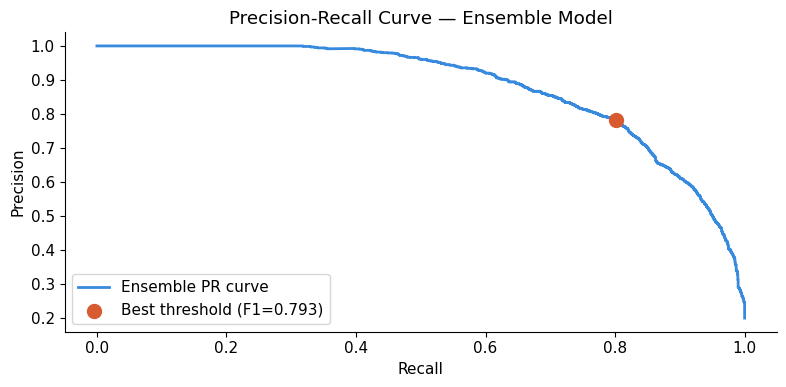

In [44]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, ensemble_scores)
f1_curve = np.where(
    (precisions + recalls) > 0,
    2 * precisions * recalls / (precisions + recalls), 0
)
best_idx       = np.argmax(f1_curve[:-1])
best_threshold = thresholds[best_idx]

print(f"Optimal ensemble threshold : {best_threshold:.4f}")
print(f"  At this threshold → Precision={precisions[best_idx]:.3f}  "
      f"Recall={recalls[best_idx]:.3f}  F1={f1_curve[best_idx]:.3f}")

# Plot PR curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(recalls, precisions, color="#378ADD", lw=2, label="Ensemble PR curve")
ax.scatter(recalls[best_idx], precisions[best_idx],
           color="#D85A30", s=100, zorder=5, label=f"Best threshold (F1={f1_curve[best_idx]:.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — Ensemble Model")
ax.legend(); plt.tight_layout()
plt.savefig("plot_pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()


Rule Based Safety Net

In [45]:
DRUG_REF = {
    "Paracetamol":             {"dose_per_kg_min":10.0, "dose_per_kg_max":15.0, "freq_max":6, "min_age_months":0,  "min_weight_kg":2.5, "max_single_dose_mg":1000.0},
    "Amoxicillin":             {"dose_per_kg_min":8.0,  "dose_per_kg_max":15.0, "freq_max":3, "min_age_months":0,  "min_weight_kg":2.5, "max_single_dose_mg":500.0},
    "Cotrimoxazole":           {"dose_per_kg_min":4.0,  "dose_per_kg_max":6.0,  "freq_max":2, "min_age_months":2,  "min_weight_kg":3.0, "max_single_dose_mg":480.0},
    "Ibuprofen":               {"dose_per_kg_min":5.0,  "dose_per_kg_max":10.0, "freq_max":4, "min_age_months":3,  "min_weight_kg":7.0, "max_single_dose_mg":400.0},
    "Metronidazole":           {"dose_per_kg_min":7.0,  "dose_per_kg_max":10.0, "freq_max":3, "min_age_months":0,  "min_weight_kg":2.5, "max_single_dose_mg":500.0},
    "Chloramphenicol":         {"dose_per_kg_min":12.0, "dose_per_kg_max":25.0, "freq_max":4, "min_age_months":1,  "min_weight_kg":4.0, "max_single_dose_mg":1000.0},
    "Gentamicin":              {"dose_per_kg_min":2.0,  "dose_per_kg_max":7.5,  "freq_max":2, "min_age_months":0,  "min_weight_kg":1.5, "max_single_dose_mg":320.0},
    "Ceftriaxone":             {"dose_per_kg_min":25.0, "dose_per_kg_max":50.0, "freq_max":2, "min_age_months":0,  "min_weight_kg":2.0, "max_single_dose_mg":2000.0},
    "Phenobarbital":           {"dose_per_kg_min":1.5,  "dose_per_kg_max":5.0,  "freq_max":2, "min_age_months":0,  "min_weight_kg":2.0, "max_single_dose_mg":200.0},
    "Fluconazole":             {"dose_per_kg_min":3.0,  "dose_per_kg_max":12.0, "freq_max":1, "min_age_months":0,  "min_weight_kg":3.0, "max_single_dose_mg":400.0},
    "Zinc_Sulfate":            {"dose_per_kg_min":0.0,  "dose_per_kg_max":99.0, "freq_max":1, "min_age_months":0,  "min_weight_kg":2.5, "max_single_dose_mg":20.0},
    "Artemether_Lumefantrine": {"dose_per_kg_min":0.0,  "dose_per_kg_max":99.0, "freq_max":2, "min_age_months":2,  "min_weight_kg":5.0, "max_single_dose_mg":80.0},
    "Ferrous_Sulfate":         {"dose_per_kg_min":3.0,  "dose_per_kg_max":6.0,  "freq_max":2, "min_age_months":1,  "min_weight_kg":3.0, "max_single_dose_mg":200.0},
    "Zidovudine_Lamivudine":   {"dose_per_kg_min":6.0,  "dose_per_kg_max":9.0,  "freq_max":2, "min_age_months":0,  "min_weight_kg":3.0, "max_single_dose_mg":300.0},
}

def apply_rules(row):
    drug = row.get("drug_name", "")
    ref  = DRUG_REF.get(drug, {})
    if not ref: return 0, ""

    if row["dose_mg"] > ref["max_single_dose_mg"]:
        return 1, f"R1: dose {row['dose_mg']}mg > max {ref['max_single_dose_mg']}mg"
    if row["freq_per_day"] > ref["freq_max"]:
        return 1, f"R2: freq {row['freq_per_day']}/day > max {ref['freq_max']}/day"
    if row["age_months"] < ref["min_age_months"]:
        return 1, f"R3: {drug} contraindicated under {ref['min_age_months']}m"
    if row["weight_kg"] < ref["min_weight_kg"]:
        return 1, f"R4: {drug} contraindicated under {ref['min_weight_kg']}kg"
    hi = ref.get("dose_per_kg_max", 0)
    if hi and row["dose_per_kg"] > hi * 3:
        return 1, f"R5: dose/kg {row['dose_per_kg']:.1f} > 3× guideline max {hi}"
    lo = ref.get("dose_per_kg_min", 0)
    if lo and row["dose_per_kg"] < lo * 0.30:
        return 1, f"R6: dose/kg {row['dose_per_kg']:.1f} < 30% of min {lo}"
    return 0, ""

rules_result = test_df.apply(apply_rules, axis=1)
rule_flags   = np.array([r[0] for r in rules_result])

rule_p  = precision_score(y_test, rule_flags, zero_division=0)
rule_r  = recall_score(y_test, rule_flags, zero_division=0)
rule_f1 = f1_score(y_test, rule_flags, zero_division=0)
print(f"Rule engine alone → Precision: {rule_p:.3f}  Recall: {rule_r:.3f}  F1: {rule_f1:.3f}")

Rule engine alone → Precision: 0.970  Recall: 0.741  F1: 0.840


Hybrid Evaluation

In [47]:
# Hybrid prediction: flag if ensemble OR rules fires
ens_preds    = (ensemble_scores >= best_threshold).astype(int)
hybrid_preds = np.maximum(ens_preds, rule_flags).astype(int)
hybrid_scores = np.maximum(ensemble_scores, rule_flags.astype(float))

# ── Metrics ──────────────────────────────────────────────────────────────────
hybrid_p   = precision_score(y_test, hybrid_preds, zero_division=0)
hybrid_r   = recall_score(y_test, hybrid_preds, zero_division=0)
hybrid_f1  = f1_score(y_test, hybrid_preds, zero_division=0)
hybrid_auc = roc_auc_score(y_test, hybrid_scores)

if_only_f1 = f1_score(y_test, if_preds, zero_division=0)

print("=" * 58)
print("FINAL RESULTS — HYBRID MODEL (Ensemble + Rule Engine)")
print("=" * 58)
print(f"  Precision : {hybrid_p:.3f}")
print(f"  Recall    : {hybrid_r:.3f}")
print(f"  F1-Score  : {hybrid_f1:.3f}   (IF-only was {if_only_f1:.3f})")
print(f"  ROC-AUC   : {hybrid_auc:.3f}")
print()
print(classification_report(y_test, hybrid_preds,
      target_names=["Normal","Anomaly"], zero_division=0))

FINAL RESULTS — HYBRID MODEL (Ensemble + Rule Engine)
  Precision : 0.802
  Recall    : 0.896
  F1-Score  : 0.847   (IF-only was 0.785)
  ROC-AUC   : 0.973

              precision    recall  f1-score   support

      Normal       0.97      0.94      0.96      8000
     Anomaly       0.80      0.90      0.85      2000

    accuracy                           0.94     10000
   macro avg       0.89      0.92      0.90     10000
weighted avg       0.94      0.94      0.94     10000



Confusion Matrix

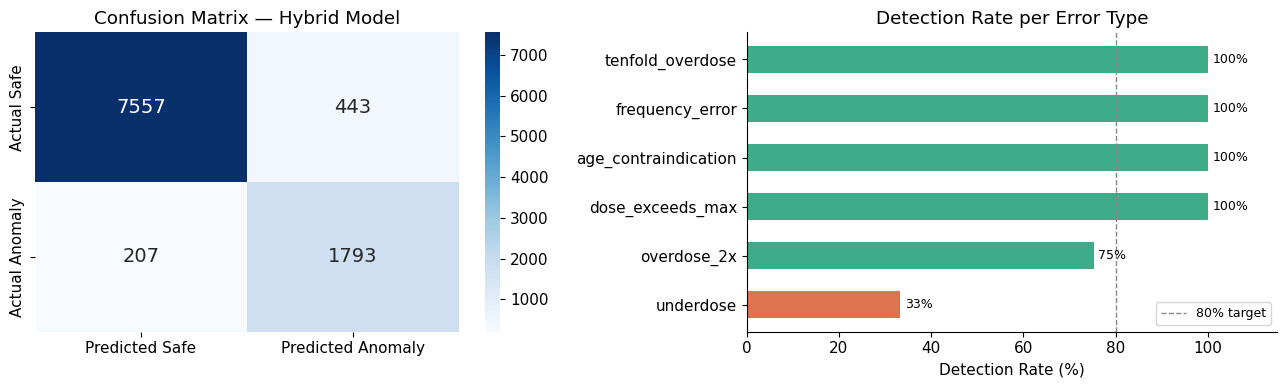


True Positives  (caught errors) : 1793
False Positives (false alarms)  : 443  → alert fatigue: 5.5%
False Negatives (missed errors) : 207
True Negatives  (correct clears): 7557


In [48]:
tn, fp, fn, tp = confusion_matrix(y_test, hybrid_preds).ravel()
alert_fatigue  = fp / (fp + tn) if (fp + tn) > 0 else 0

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion matrix heatmap
cm = confusion_matrix(y_test, hybrid_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Safe","Predicted Anomaly"],
            yticklabels=["Actual Safe","Actual Anomaly"], ax=axes[0],
            annot_kws={"size":14})
axes[0].set_title("Confusion Matrix — Hybrid Model")

# Per error type detection
anom_df = test_df.copy()
anom_df["predicted"] = hybrid_preds
grp = anom_df[anom_df["is_anomaly"]==1].groupby("anomaly_type").apply(
    lambda x: x["predicted"].sum() / len(x) * 100
).sort_values()

colors_e = ["#D85A30" if v < 70 else "#1D9E75" for v in grp.values]
axes[1].barh(grp.index, grp.values, color=colors_e, alpha=0.85, height=0.55)
axes[1].axvline(80, color="#888780", lw=1, linestyle="--", label="80% target")
axes[1].set_xlabel("Detection Rate (%)")
axes[1].set_title("Detection Rate per Error Type")
axes[1].set_xlim(0, 115)
axes[1].legend(fontsize=9)
for i, (idx, val) in enumerate(grp.items()):
    axes[1].text(val+1, i, f"{val:.0f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("plot_results.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTrue Positives  (caught errors) : {tp}")
print(f"False Positives (false alarms)  : {fp}  → alert fatigue: {alert_fatigue*100:.1f}%")
print(f"False Negatives (missed errors) : {fn}")
print(f"True Negatives  (correct clears): {tn}")

Saving Model Artifacts

In [49]:
import joblib, json, os
from datetime import datetime

os.makedirs("models", exist_ok=True)

joblib.dump(if_model,  "models/isolation_forest.pkl")
joblib.dump(lof_model, "models/lof_model.pkl")
joblib.dump(scaler,    "models/scaler.pkl")

with open("models/feature_columns.json", "w") as f:
    json.dump(MODEL_FEATURES, f, indent=2)

# Alert thresholds from normal score distribution
scores_normal    = hybrid_scores[y_test == 0]
red_threshold    = float(np.percentile(scores_normal, 92))
yellow_threshold = float(np.percentile(scores_normal, 75))

metadata = {
    "model_type":   "Hybrid: IsolationForest + LOF + RuleEngine",
    "trained_at":   datetime.now().isoformat(),
    "n_features":   len(MODEL_FEATURES),
    "features":     MODEL_FEATURES,
    "ensemble_threshold": round(float(best_threshold), 4),
    "alert_thresholds": {
        "red_threshold":    round(red_threshold, 4),
        "yellow_threshold": round(yellow_threshold, 4),
    },
    "performance": {
        "precision":    round(float(hybrid_p), 4),
        "recall":       round(float(hybrid_r), 4),
        "f1":           round(float(hybrid_f1), 4),
        "roc_auc":      round(float(hybrid_auc), 4),
        "true_positives":  int(tp),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_negatives":  int(tn),
        "alert_fatigue_rate": round(float(alert_fatigue), 4),
    },
}
with open("models/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Model artifacts saved:")
for fname in ["models/isolation_forest.pkl","models/lof_model.pkl",
              "models/scaler.pkl","models/feature_columns.json","models/model_metadata.json"]:
    size = os.path.getsize(fname)
    print(f"  ✓ {fname:<40} ({size/1024:.1f} KB)")

Model artifacts saved:
  ✓ models/isolation_forest.pkl              (77197.3 KB)
  ✓ models/lof_model.pkl                     (3204.0 KB)
  ✓ models/scaler.pkl                        (1.0 KB)
  ✓ models/feature_columns.json              (0.4 KB)
  ✓ models/model_metadata.json               (1.0 KB)
